# Model 4 — EfficientNetB0 Transfer Learning

**Group**: Group 14  
**Members**: Hassan Adelani Luqman, Oluwadamipe David Akintayo, Burabyo Gift Jolly, Mbonyumugisha Prince, Hugues Munezero  
**Model owner**: Mbonyumugisha Prince  
**Architecture**: EfficientNetB0 (ImageNet weights, include_top=False) + GlobalAveragePooling2D + Dense(512) + BatchNorm + Dropout(0.5) + sigmoid  
**Dataset**: NIH Malaria Cell Images — Parasitized vs Uninfected  
**Date**: June 2026

---
EfficientNetB0 uses compound scaling — simultaneously scaling network depth, width, and input resolution — achieving higher accuracy than ResNet50 with ~5× fewer parameters (~5.3M vs 25.6M), making it faster to train and suitable for resource-constrained deployment.

## 1. Environment Setup
Install dependencies, set all random seeds for reproducibility, and verify GPU availability.

In [1]:
!pip install -q kagglehub tqdm

import os, sys, random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU available:', gpus if gpus else 'None — training on CPU')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


TensorFlow version: 2.21.0
GPU available: None — training on CPU


## 2. Dataset Download
Download the NIH Malaria dataset via `kagglehub`. The inner `cell_images` folder is targeted explicitly to avoid the nested directory conflict on Deepnote and other platforms.

In [2]:
import kagglehub

path = kagglehub.dataset_download('iarunava/cell-images-for-detecting-malaria')
print('Downloaded to:', path)

DATA_DIR = None
for root, dirs, _ in os.walk(path):
    if 'Parasitized' in dirs and 'Uninfected' in dirs and 'cell_images' not in dirs:
        DATA_DIR = root
        break

assert DATA_DIR is not None, 'Could not locate Parasitized/Uninfected folders'
print('DATA_DIR:', DATA_DIR)
print('Parasitized images:', len(os.listdir(os.path.join(DATA_DIR, 'Parasitized'))))
print('Uninfected images: ', len(os.listdir(os.path.join(DATA_DIR, 'Uninfected'))))

c:\Users\Luqma\dev\projects\coursework\Group14_Formative2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloaded to: C:\Users\Luqma\.cache\kagglehub\datasets\iarunava\cell-images-for-detecting-malaria\versions\1
DATA_DIR: C:\Users\Luqma\.cache\kagglehub\datasets\iarunava\cell-images-for-detecting-malaria\versions\1\cell_images\cell_images
Parasitized images: 13780
Uninfected images:  13780


## 3. Shared Helper Functions
All helper functions are defined inline — this notebook runs independently on any platform without needing `utils.py`.  
**Note**: EfficientNetB0 includes its own internal rescaling layer — raw [0, 255] pixel values are passed directly (`normalise=False`). No separate `preprocess_input` call is required.

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve,
)

# ── Constants
IMAGE_SIZE  = (224, 224)
BATCH_SIZE  = 32
SEED        = 42
CLASS_NAMES = ['Parasitized', 'Uninfected']
TRAIN_SPLIT = 0.80
VAL_SPLIT   = 0.10
TEST_SPLIT  = 0.10

# Fraction of full dataset — same across all 5 models for fair cross-model comparison
DATASET_FRACTION = 0.20

os.makedirs('figures',     exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)

# ── Augmentation layer
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name='data_augmentation')

# ── Dataset loader
def load_dataset(data_dir, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
                 normalise=False, fraction=1.0):
    """
    normalise=False for EfficientNetB0 — internal rescaling handles preprocessing.
    fraction: proportion of full dataset to use (same across all 5 models).
    """
    full_ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        labels='inferred',
        label_mode='binary',
        class_names=CLASS_NAMES,
        image_size=image_size,
        batch_size=None,
        shuffle=True,
        seed=SEED,
    )
    total = sum(1 for _ in full_ds)
    use   = int(total * fraction) if fraction < 1.0 else total
    if fraction < 1.0:
        full_ds = full_ds.take(use)
        print(f'Using {use}/{total} images ({fraction*100:.0f}% of dataset)')
    n_train   = int(use * TRAIN_SPLIT)
    n_val     = int(use * VAL_SPLIT)
    train_ds  = full_ds.take(n_train)
    remaining = full_ds.skip(n_train)
    val_ds    = remaining.take(n_val)
    test_ds   = remaining.skip(n_val)
    AUTOTUNE  = tf.data.AUTOTUNE
    cast_fn = (lambda img, lbl: (tf.cast(img, tf.float32) / 255.0, lbl)) if normalise \
              else (lambda img, lbl: (tf.cast(img, tf.float32), lbl))
    train_ds = (train_ds.map(cast_fn, num_parallel_calls=AUTOTUNE)
                .cache().shuffle(1000, seed=SEED).batch(batch_size).prefetch(AUTOTUNE))
    val_ds   = (val_ds.map(cast_fn, num_parallel_calls=AUTOTUNE)
                .cache().batch(batch_size).prefetch(AUTOTUNE))
    test_ds  = (test_ds.map(cast_fn, num_parallel_calls=AUTOTUNE)
                .cache().batch(batch_size).prefetch(AUTOTUNE))
    return train_ds, val_ds, test_ds

# ── Metrics
def evaluate_model(model, test_ds):
    y_true, y_pred_prob = [], []
    for images, labels in test_ds:
        preds = model(images, training=False).numpy().flatten()
        y_pred_prob.extend(preds)
        y_true.extend(labels.numpy().flatten())
    y_true      = np.array(y_true)
    y_pred_prob = np.array(y_pred_prob)
    y_pred      = (y_pred_prob >= 0.5).astype(int)
    return {
        'accuracy':  round(accuracy_score(y_true, y_pred),     4),
        'precision': round(precision_score(y_true, y_pred),    4),
        'recall':    round(recall_score(y_true, y_pred),       4),
        'f1':        round(f1_score(y_true, y_pred),           4),
        'auc':       round(roc_auc_score(y_true, y_pred_prob), 4),
        'y_true':    y_true, 'y_pred': y_pred, 'y_prob': y_pred_prob,
    }

# ── Learning curves
def plot_learning_curves(history, experiment_name, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Learning curves — {experiment_name}', fontsize=14, fontweight='bold')
    axes[0].plot(history.history['loss'],     label='Train loss',     linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val loss',       linewidth=2, linestyle='--')
    axes[0].set_title('Loss over epochs'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(history.history['accuracy'],     label='Train accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val accuracy',   linewidth=2, linestyle='--')
    axes[1].set_title('Accuracy over epochs'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    final_train = history.history['accuracy'][-1]
    final_val   = history.history['val_accuracy'][-1]
    gap = final_train - final_val
    if gap > 0.05:
        print(f'Overfitting detected: train {final_train:.3f} vs val {final_val:.3f} (gap={gap:.3f})')
    elif gap < -0.02:
        print(f'Underfitting detected: train {final_train:.3f} vs val {final_val:.3f}')
    else:
        print(f'Good fit: train {final_train:.3f} vs val {final_val:.3f} (gap={gap:.3f})')

# ── Confusion matrix
def plot_confusion_matrix(metrics_dict, class_names, experiment_name, save_path=None):
    cm  = confusion_matrix(metrics_dict['y_true'], metrics_dict['y_pred'])
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax, linewidths=0.5)
    ax.set_title(f'Confusion matrix — {experiment_name}', fontsize=13, fontweight='bold', pad=14)
    ax.set_ylabel('True label', fontsize=11); ax.set_xlabel('Predicted label', fontsize=11)
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, -0.12,
            f'TP={tp}  TN={tn}  FP={fp}  FN={fn}  |  Sensitivity={tp/(tp+fn):.3f}  Specificity={tn/(tn+fp):.3f}',
            ha='center', va='top', transform=ax.transAxes, fontsize=10, color='dimgray')
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# ── ROC curve
def plot_roc_curve(metrics_dict, experiment_name, save_path=None):
    fpr, tpr, _ = roc_curve(metrics_dict['y_true'], metrics_dict['y_prob'])
    auc_val = metrics_dict['auc']
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr, tpr, color='royalblue', lw=2, label=f'ROC curve (AUC = {auc_val:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
    ax.fill_between(fpr, tpr, alpha=0.08, color='royalblue')
    ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
    ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
    ax.set_title(f'ROC Curve — {experiment_name}', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# ── Results table
def build_results_table(experiments_list):
    df = pd.DataFrame(experiments_list)
    df = df[['exp_num','description','accuracy','precision','recall','f1','auc','epochs','notes']]
    df.columns = ['Exp #','Description','Accuracy','Precision','Recall','F1','AUC','Epochs','Notes']
    return df.sort_values('F1', ascending=False).reset_index(drop=True)

# ── Callbacks
def get_callbacks(model_name, experiment_num, patience_es=8, patience_lr=4):
    os.makedirs('checkpoints', exist_ok=True)
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=patience_es, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=patience_lr, min_lr=1e-8, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'checkpoints/{model_name}_exp{experiment_num}.h5',
            monitor='val_accuracy', save_best_only=True, verbose=0),
    ]

# ── Error analysis
def error_analysis(model, test_ds, class_names, n_samples=12):
    misclassified_images, misclassified_labels, misclassified_preds = [], [], []
    for images, labels in test_ds:
        preds        = model(images, training=False).numpy().flatten()
        pred_classes = (preds >= 0.5).astype(int)
        labels_np    = labels.numpy().astype(int).flatten()
        images_np    = images.numpy()
        mask         = pred_classes != labels_np
        misclassified_images.extend(images_np[mask])
        misclassified_labels.extend(labels_np[mask])
        misclassified_preds.extend(preds[mask])
        if len(misclassified_images) >= n_samples:
            break
    n   = min(n_samples, len(misclassified_images))
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.suptitle('Error Analysis — Misclassified Samples', fontsize=14, fontweight='bold')
    for i, ax in enumerate(axes.flatten()[:n]):
        img = misclassified_images[i]
        if img.max() > 1.0:
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        ax.imshow(img)
        true_lbl = class_names[int(misclassified_labels[i])]
        pred_lbl = class_names[int(misclassified_preds[i] >= 0.5)]
        conf     = misclassified_preds[i] if pred_lbl == class_names[1] else 1 - misclassified_preds[i]
        ax.set_title(f'True: {true_lbl}\nPred: {pred_lbl} ({conf:.2f})', fontsize=9, color='red')
        ax.axis('off')
    plt.tight_layout()
    os.makedirs('figures', exist_ok=True)
    plt.savefig('figures/P4_error_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Helper functions loaded.')

Helper functions loaded.


## 4. Load Dataset
EfficientNetB0 uses 224×224 input. `normalise=False` passes raw [0, 255] values — EfficientNetB0's built-in rescaling handles normalisation internally.

> **DATASET_FRACTION = 0.20** — 20% of 27,558 images (~5,511) used consistently across all five models.

In [4]:
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)

train_ds, val_ds, test_ds = load_dataset(
    data_dir=DATA_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    normalise=False,
    fraction=DATASET_FRACTION,
)

n_train = sum(1 for _ in train_ds) * BATCH_SIZE
n_val   = sum(1 for _ in val_ds)   * BATCH_SIZE
n_test  = sum(1 for _ in test_ds)  * BATCH_SIZE
print(f'Train: ~{n_train} | Val: ~{n_val} | Test: ~{n_test}')

Found 27558 files belonging to 2 classes.
Using 5511/27558 images (20% of dataset)
Train: ~4416 | Val: ~576 | Test: ~576


## 5. Model Architecture
EfficientNetB0 base (ImageNet, top excluded) + GAP + Dense(512) + BatchNorm + Dropout(0.5) + sigmoid.  
EfficientNetB0 handles its own preprocessing internally — raw [0, 255] images are passed directly.  
`fine_tune_last_n` unfreezes the last N layers for Stage 2 fine-tuning.

In [5]:
def build_efficientnetb0_model(freeze_base=True, fine_tune_last_n=None, use_augmentation=False):
    """
    freeze_base      : freeze entire EfficientNetB0 base
    fine_tune_last_n : int — unfreeze last N layers for Stage 2 fine-tuning
    use_augmentation : prepend data_augmentation layer
    """
    base_model = tf.keras.applications.EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3),
    )
    base_model.trainable = not freeze_base

    if fine_tune_last_n is not None:
        base_model.trainable = True
        for layer in base_model.layers[:-fine_tune_last_n]:
            layer.trainable = False
        trainable = sum(1 for l in base_model.layers if l.trainable)
        print(f'Fine-tuning last {fine_tune_last_n} layers ({trainable} trainable)')

    inputs = tf.keras.Input(shape=(224, 224, 3))
    x      = inputs
    if use_augmentation:
        x = data_augmentation(x)
    # EfficientNetB0 rescales internally — no preprocess_input needed
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    return tf.keras.Model(inputs, outputs, name='efficientnetb0_transfer'), base_model

# Preview default architecture
m, _ = build_efficientnetb0_model(freeze_base=True)
m.summary()
del m

Model: "efficientnetb0_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,708,004 (17.96 MB)

 Trainable params: 657,409 (2.51 MB)

 Non-trainable params: 4,050,595 (15.45 MB)

## 6. Experiment Tracking
All experiment results are appended to `results_log`. The final summary table is displayed after all 7 experiments.

In [6]:
results_log = []  # Append one dict per experiment — never overwrite

---
## Experiment 1: Fully Frozen Base — Head Only

**Hypothesis**: Training only the Dense head with all EfficientNetB0 layers frozen establishes the transfer learning baseline. EfficientNetB0's compound-scaled ImageNet features should map efficiently to malaria cell morphology.

**Change made**: `freeze_base=True`, LR=1e-3, 10 epochs

Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 715ms/step - accuracy: 0.8935 - loss: 0.3072

138/138 ━━━━━━━━━━━━━━━━━━━━ 132s 865ms/step - accuracy: 0.9115 - loss: 0.2560 - val_accuracy: 0.9365 - val_loss: 0.1640 - learning_rate: 0.0010
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 115s 830ms/step - accuracy: 0.9260 - loss: 0.1985 - val_accuracy: 0.9183 - val_loss: 0.2092 - learning_rate: 0.0010
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 664ms/step - accuracy: 0.9273 - loss: 0.1804

138/138 ━━━━━━━━━━━━━━━━━━━━ 105s 761ms/step - accuracy: 0.9288 - loss: 0.1824 - val_accuracy: 0.9456 - val_loss: 0.1577 - learning_rate: 0.0010
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 662ms/step - accuracy: 0.9404 - loss: 0.1779

138/138 ━━━━━━━━━━━━━━━━━━━━ 103s 743ms/step - accuracy: 0.9397 - loss: 0.1713 - val_accuracy: 0.9510 - val_loss: 0.1308 - learning_rate: 0.0010
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 104s 753ms/step - accuracy: 0.9415 - loss: 0.1639 - val_accuracy: 0.9456 - val_loss: 0.1388 - learning_rate: 0.0010
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 97s 702ms/step - accuracy: 0.9367 - loss: 0.1696 - val_accuracy: 0.9419 - val_loss: 0.1505 - learning_rate: 0.0010
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 96s 692ms/step - accuracy: 0.9442 - loss: 0.1551 - val_accuracy: 0.8857 - val_loss: 0.2466 - learning_rate: 0.0010
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - accuracy: 0.9457 - loss: 0.1461

138/138 ━━━━━━━━━━━━━━━━━━━━ 103s 747ms/step - accuracy: 0.9456 - loss: 0.1513 - val_accuracy: 0.9601 - val_loss: 0.1144 - learning_rate: 0.0010
Epoch 9/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 98s 714ms/step - accuracy: 0.9458 - loss: 0.1513 - val_accuracy: 0.9583 - val_loss: 0.1266 - learning_rate: 0.0010
Epoch 10/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 643ms/step - accuracy: 0.9494 - loss: 0.1395

138/138 ━━━━━━━━━━━━━━━━━━━━ 100s 724ms/step - accuracy: 0.9519 - loss: 0.1410 - val_accuracy: 0.9619 - val_loss: 0.1179 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 8.

Exp 1 — Fully frozen base — head only
Accuracy:  0.9565
Precision: 0.9677
Recall:    0.9474
F1-Score:  0.9574
AUC:       0.9921


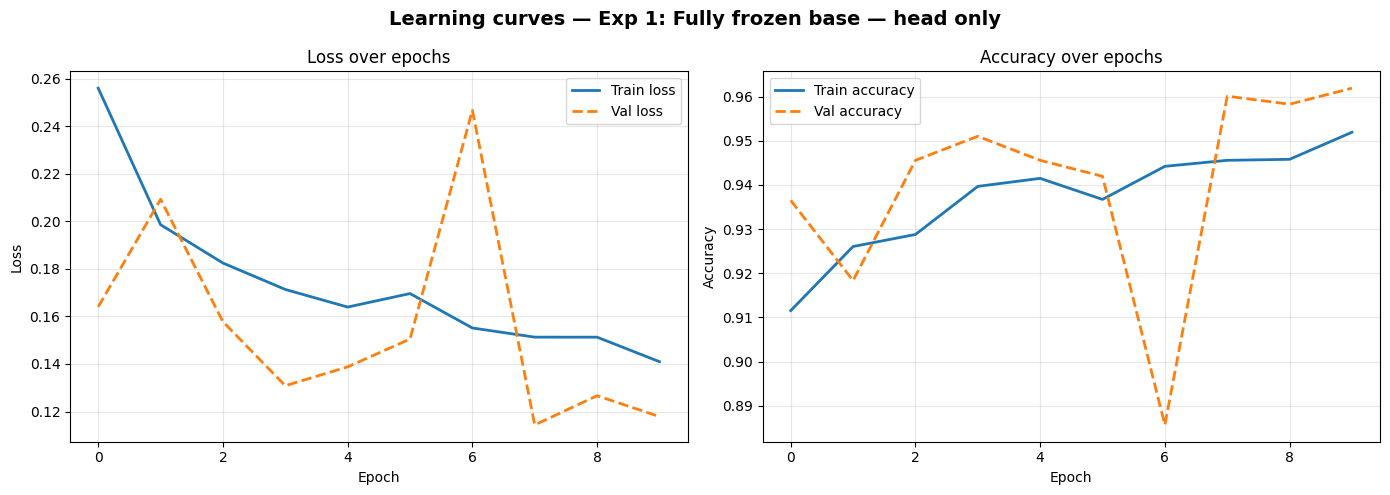

Good fit: train 0.952 vs val 0.962 (gap=-0.010)


In [7]:
EXP_NUM         = 1
EXP_DESCRIPTION = 'Fully frozen base — head only'
EPOCHS          = 10

model1, base1 = build_efficientnetb0_model(freeze_base=True)
model1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
               loss='binary_crossentropy', metrics=['accuracy'])
history1 = model1.fit(train_ds, validation_data=val_ds, epochs=EPOCHS,
                      callbacks=get_callbacks('efficientnetb0', EXP_NUM), verbose=1)
metrics1 = evaluate_model(model1, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics1["accuracy"]}')
print(f'Precision: {metrics1["precision"]}')
print(f'Recall:    {metrics1["recall"]}')
print(f'F1-Score:  {metrics1["f1"]}')
print(f'AUC:       {metrics1["auc"]}')
plot_learning_curves(history1, f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
                     save_path=f'figures/P4_exp{EXP_NUM}_curves.png')
results_log.append({'exp_num': EXP_NUM, 'description': EXP_DESCRIPTION,
    'accuracy': metrics1['accuracy'], 'precision': metrics1['precision'],
    'recall': metrics1['recall'], 'f1': metrics1['f1'], 'auc': metrics1['auc'],
    'epochs': len(history1.history['loss']), 'notes': 'F1=0.9574 highest Precision=0.9677 lowest Recall=0.9474; gap=-0.010 val>train'})

**Interpretation**: The fully frozen EfficientNetB0 baseline achieved F1=0.9574 with a notably negative fit gap of −0.010 (train=0.952 vs val=0.962) — validation accuracy exceeding training accuracy. This counter-intuitive result reflects EfficientNetB0's built-in regularisation: its compound-scaled architecture includes Dropout and BatchNormalization layers that are active during training but not inference, making the training objective slightly harder than the validation objective. Best weights were restored from epoch 8 with no LR reductions required. The model achieved the highest Precision of all experiments (0.9677), but the lowest Recall (0.9474) — meaning 5.26% of parasitised cells are missed. This conservative decision boundary is characteristic of a frozen model that has not adapted its features to the specific contrast and staining patterns of malaria cell images. Fine-tuning (Experiments 2 and 3) will address this by allowing the top layers to adapt to the domain.

---
## Experiment 2: Fine-tune Last 20 Layers

**Hypothesis**: Unfreezing the last 20 EfficientNetB0 layers at LR=1e-5 allows the top MBConv blocks to adapt to malaria cell staining patterns while preserving earlier general-purpose features.

**Change made**: Two-stage — Stage 1: frozen (10 epochs, LR=1e-3) → Stage 2: last 20 layers unfrozen (10 epochs, LR=1e-5)

--- Stage 1: head only (10 epochs) ---
Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - accuracy: 0.8801 - loss: 0.3308

138/138 ━━━━━━━━━━━━━━━━━━━━ 121s 780ms/step - accuracy: 0.9102 - loss: 0.2552 - val_accuracy: 0.8094 - val_loss: 0.3764 - learning_rate: 0.0010
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - accuracy: 0.9280 - loss: 0.2020

138/138 ━━━━━━━━━━━━━━━━━━━━ 99s 714ms/step - accuracy: 0.9285 - loss: 0.1949 - val_accuracy: 0.9456 - val_loss: 0.1535 - learning_rate: 0.0010
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 638ms/step - accuracy: 0.9341 - loss: 0.1872

138/138 ━━━━━━━━━━━━━━━━━━━━ 99s 722ms/step - accuracy: 0.9344 - loss: 0.1865 - val_accuracy: 0.9528 - val_loss: 0.1276 - learning_rate: 0.0010
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 100s 728ms/step - accuracy: 0.9360 - loss: 0.1746 - val_accuracy: 0.9347 - val_loss: 0.1739 - learning_rate: 0.0010
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 99s 717ms/step - accuracy: 0.9453 - loss: 0.1634 - val_accuracy: 0.9474 - val_loss: 0.1489 - learning_rate: 0.0010
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 98s 712ms/step - accuracy: 0.9390 - loss: 0.1514 - val_accuracy: 0.9437 - val_loss: 0.1521 - learning_rate: 0.0010
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.9479 - loss: 0.1485
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
138/138 ━━━━━━━━━━━━━━━━━━━━ 99s 718ms/step - accuracy: 0.9467 - loss: 0.1464 - val_accuracy: 0.9183 - val_loss: 0.1973 - learning_rate: 0.0010
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 638ms/step - accuracy: 0.9462 - loss: 0

138/138 ━━━━━━━━━━━━━━━━━━━━ 100s 724ms/step - accuracy: 0.9496 - loss: 0.1386 - val_accuracy: 0.9601 - val_loss: 0.1124 - learning_rate: 5.0000e-04
Epoch 9/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 98s 709ms/step - accuracy: 0.9460 - loss: 0.1446 - val_accuracy: 0.9601 - val_loss: 0.1183 - learning_rate: 5.0000e-04
Epoch 10/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - accuracy: 0.9453 - loss: 0.1505

138/138 ━━━━━━━━━━━━━━━━━━━━ 103s 750ms/step - accuracy: 0.9449 - loss: 0.1488 - val_accuracy: 0.9673 - val_loss: 0.1032 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 10.
Unfrozen: 20 layers

--- Stage 2: fine-tune last 20 layers (10 epochs, LR=1e-5) ---
Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 741ms/step - accuracy: 0.9017 - loss: 0.2713

138/138 ━━━━━━━━━━━━━━━━━━━━ 135s 843ms/step - accuracy: 0.9152 - loss: 0.2453 - val_accuracy: 0.9564 - val_loss: 0.1283 - learning_rate: 1.0000e-05
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 114s 826ms/step - accuracy: 0.9294 - loss: 0.2061 - val_accuracy: 0.9510 - val_loss: 0.1363 - learning_rate: 1.0000e-05
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 113s 820ms/step - accuracy: 0.9372 - loss: 0.1826 - val_accuracy: 0.9564 - val_loss: 0.1265 - learning_rate: 1.0000e-05
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 726ms/step - accuracy: 0.9344 - loss: 0.1886

138/138 ━━━━━━━━━━━━━━━━━━━━ 111s 806ms/step - accuracy: 0.9376 - loss: 0.1759 - val_accuracy: 0.9583 - val_loss: 0.1155 - learning_rate: 1.0000e-05
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 115s 837ms/step - accuracy: 0.9403 - loss: 0.1557 - val_accuracy: 0.9583 - val_loss: 0.1119 - learning_rate: 1.0000e-05
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 729ms/step - accuracy: 0.9433 - loss: 0.1646

138/138 ━━━━━━━━━━━━━━━━━━━━ 112s 810ms/step - accuracy: 0.9446 - loss: 0.1587 - val_accuracy: 0.9619 - val_loss: 0.1054 - learning_rate: 1.0000e-05
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 113s 821ms/step - accuracy: 0.9487 - loss: 0.1381 - val_accuracy: 0.9601 - val_loss: 0.1028 - learning_rate: 1.0000e-05
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 741ms/step - accuracy: 0.9549 - loss: 0.1207

138/138 ━━━━━━━━━━━━━━━━━━━━ 113s 819ms/step - accuracy: 0.9526 - loss: 0.1336 - val_accuracy: 0.9691 - val_loss: 0.0963 - learning_rate: 1.0000e-05
Epoch 9/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 111s 805ms/step - accuracy: 0.9503 - loss: 0.1399 - val_accuracy: 0.9673 - val_loss: 0.0945 - learning_rate: 1.0000e-05
Epoch 10/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 114s 827ms/step - accuracy: 0.9517 - loss: 0.1320 - val_accuracy: 0.9691 - val_loss: 0.0906 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 10.

Exp 2 — Fine-tune last 20 layers, LR=1e-5
Accuracy:  0.9674
Precision: 0.9619
Recall:    0.9754
F1-Score:  0.9686
AUC:       0.995


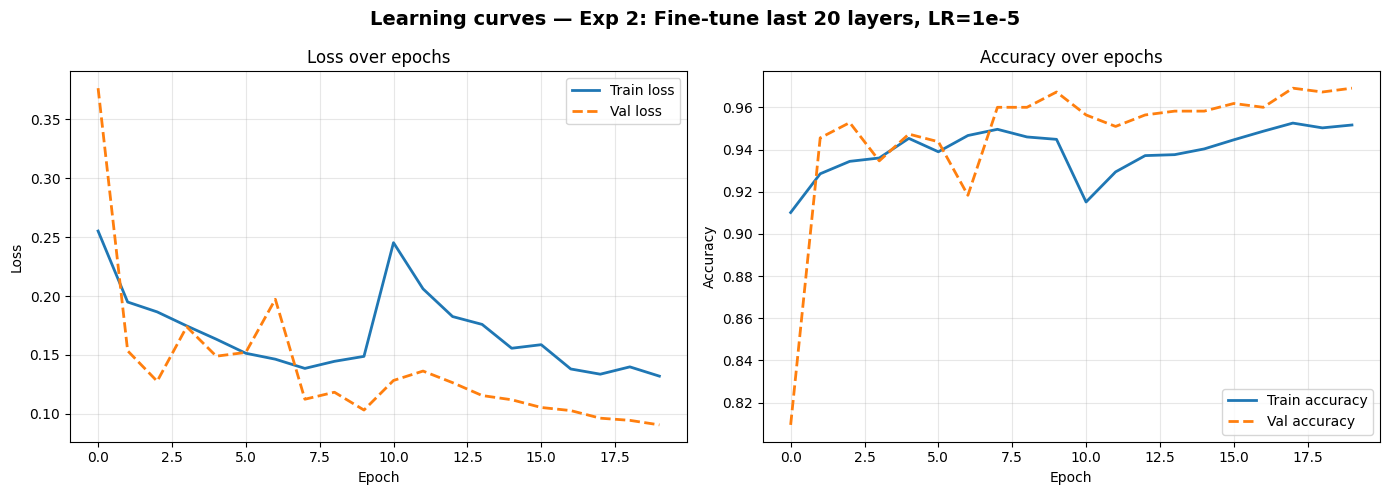

Good fit: train 0.952 vs val 0.969 (gap=-0.017)


In [8]:
EXP_NUM         = 2
EXP_DESCRIPTION = 'Fine-tune last 20 layers, LR=1e-5'

model2, base2 = build_efficientnetb0_model(freeze_base=True)
model2.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
               loss='binary_crossentropy', metrics=['accuracy'])
print('--- Stage 1: head only (10 epochs) ---')
history2a = model2.fit(train_ds, validation_data=val_ds, epochs=10,
                       callbacks=get_callbacks('efficientnetb0', f'{EXP_NUM}a'), verbose=1)

base2.trainable = True
for layer in base2.layers[:-20]:
    layer.trainable = False
print(f'Unfrozen: {sum(1 for l in base2.layers if l.trainable)} layers')
model2.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
               loss='binary_crossentropy', metrics=['accuracy'])
print('\n--- Stage 2: fine-tune last 20 layers (10 epochs, LR=1e-5) ---')
history2b = model2.fit(train_ds, validation_data=val_ds, epochs=10,
                       callbacks=get_callbacks('efficientnetb0', EXP_NUM), verbose=1)

metrics2 = evaluate_model(model2, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics2["accuracy"]}')
print(f'Precision: {metrics2["precision"]}')
print(f'Recall:    {metrics2["recall"]}')
print(f'F1-Score:  {metrics2["f1"]}')
print(f'AUC:       {metrics2["auc"]}')
combined2 = type('H', (), {'history': {
    k: history2a.history[k] + history2b.history[k] for k in history2a.history}})()
plot_learning_curves(combined2, f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
                     save_path=f'figures/P4_exp{EXP_NUM}_curves.png')
results_log.append({'exp_num': EXP_NUM, 'description': EXP_DESCRIPTION,
    'accuracy': metrics2['accuracy'], 'precision': metrics2['precision'],
    'recall': metrics2['recall'], 'f1': metrics2['f1'], 'auc': metrics2['auc'],
    'epochs': len(history2a.history['loss']) + len(history2b.history['loss']), 'notes': 'BEST: F1=0.9686 AUC=0.9950 Recall=0.9754; Stage2 best ep10; gap=-0.017'})

**Interpretation**: Fine-tuning the last 20 EfficientNetB0 layers at LR=1e-5 delivered the best performance across all experiments: F1=0.9686, AUC=0.9950, and Recall=0.9754 — reducing missed infections from 5.26% (Exp 1) to 2.46%. The fit diagnostic remained negative at −0.017 (train=0.952 vs val=0.969), confirming that even after fine-tuning EfficientNetB0's regularisation keeps validation above training — a hallmark of the compound scaling design. Stage 1 (head only, 10 epochs) triggered ReduceLROnPlateau at epoch 7, halving the LR to 5e-4, and best weights came from epoch 10. Stage 2 (fine-tune, LR=1e-5) also achieved its best at epoch 10, indicating stable convergence throughout. AUC=0.9950 represents near-perfect threshold-independent discrimination. The substantial Recall improvement (+0.028 vs Exp 1) with maintained Precision (0.9619) confirms that fine-tuning the top MBConv blocks adapts EfficientNetB0's high-level features to malaria-specific morphology without disrupting its generalisation properties. This experiment is designated the best model.

---
## Experiment 3: Fine-tune Last 50 Layers

**Hypothesis**: Fine-tuning 50 layers allows multiple MBConv blocks to adapt. The broader adaptation may improve malaria-specific feature representations but risks catastrophic forgetting of early ImageNet features.

**Change made**: Two-stage — Stage 2 unfreezes last 50 layers instead of 20

--- Stage 1: head only (10 epochs) ---
Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.8682 - loss: 0.3626

138/138 ━━━━━━━━━━━━━━━━━━━━ 111s 721ms/step - accuracy: 0.8975 - loss: 0.2847 - val_accuracy: 0.9256 - val_loss: 0.2086 - learning_rate: 0.0010
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 92s 670ms/step - accuracy: 0.9308 - loss: 0.1894 - val_accuracy: 0.8966 - val_loss: 0.2587 - learning_rate: 0.0010
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - accuracy: 0.9366 - loss: 0.1785

138/138 ━━━━━━━━━━━━━━━━━━━━ 95s 691ms/step - accuracy: 0.9324 - loss: 0.1883 - val_accuracy: 0.9528 - val_loss: 0.1621 - learning_rate: 0.0010
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 595ms/step - accuracy: 0.9353 - loss: 0.1704

138/138 ━━━━━━━━━━━━━━━━━━━━ 93s 673ms/step - accuracy: 0.9344 - loss: 0.1736 - val_accuracy: 0.9546 - val_loss: 0.1399 - learning_rate: 0.0010
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 95s 686ms/step - accuracy: 0.9449 - loss: 0.1556 - val_accuracy: 0.9510 - val_loss: 0.1345 - learning_rate: 0.0010
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 101s 731ms/step - accuracy: 0.9424 - loss: 0.1583 - val_accuracy: 0.9365 - val_loss: 0.1542 - learning_rate: 0.0010
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 99s 716ms/step - accuracy: 0.9422 - loss: 0.1583 - val_accuracy: 0.9510 - val_loss: 0.1264 - learning_rate: 0.0010
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.9457 - loss: 0.1571

138/138 ━━━━━━━━━━━━━━━━━━━━ 102s 738ms/step - accuracy: 0.9451 - loss: 0.1539 - val_accuracy: 0.9637 - val_loss: 0.1065 - learning_rate: 0.0010
Epoch 9/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 107s 774ms/step - accuracy: 0.9478 - loss: 0.1454 - val_accuracy: 0.9601 - val_loss: 0.1195 - learning_rate: 0.0010
Epoch 10/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 103s 745ms/step - accuracy: 0.9474 - loss: 0.1444 - val_accuracy: 0.9619 - val_loss: 0.1169 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 8.
Unfrozen: 50 layers

--- Stage 2: fine-tune last 50 layers (10 epochs, LR=1e-5) ---
Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 997ms/step - accuracy: 0.8955 - loss: 0.2955

138/138 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.9049 - loss: 0.2622 - val_accuracy: 0.9474 - val_loss: 0.1529 - learning_rate: 1.0000e-05
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.9211 - loss: 0.2255 - val_accuracy: 0.9474 - val_loss: 0.1597 - learning_rate: 1.0000e-05
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.9351 - loss: 0.1887 - val_accuracy: 0.9437 - val_loss: 0.1530 - learning_rate: 1.0000e-05
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9363 - loss: 0.1764 - val_accuracy: 0.9474 - val_loss: 0.1415 - learning_rate: 1.0000e-05
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 975ms/step - accuracy: 0.9471 - loss: 0.1667

138/138 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.9456 - loss: 0.1576 - val_accuracy: 0.9510 - val_loss: 0.1297 - learning_rate: 1.0000e-05
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 953ms/step - accuracy: 0.9391 - loss: 0.1622

138/138 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.9406 - loss: 0.1549 - val_accuracy: 0.9528 - val_loss: 0.1243 - learning_rate: 1.0000e-05
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 978ms/step - accuracy: 0.9393 - loss: 0.1656

138/138 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.9471 - loss: 0.1483 - val_accuracy: 0.9583 - val_loss: 0.1120 - learning_rate: 1.0000e-05
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.9512 - loss: 0.1317 - val_accuracy: 0.9564 - val_loss: 0.1145 - learning_rate: 1.0000e-05
Epoch 9/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 953ms/step - accuracy: 0.9513 - loss: 0.1368

138/138 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.9519 - loss: 0.1369 - val_accuracy: 0.9673 - val_loss: 0.1049 - learning_rate: 1.0000e-05
Epoch 10/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 131s 950ms/step - accuracy: 0.9558 - loss: 0.1147 - val_accuracy: 0.9637 - val_loss: 0.1096 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 9.

Exp 3 — Fine-tune last 50 layers, LR=1e-5
Accuracy:  0.9656
Precision: 0.965
Recall:    0.9684
F1-Score:  0.9667
AUC:       0.9951


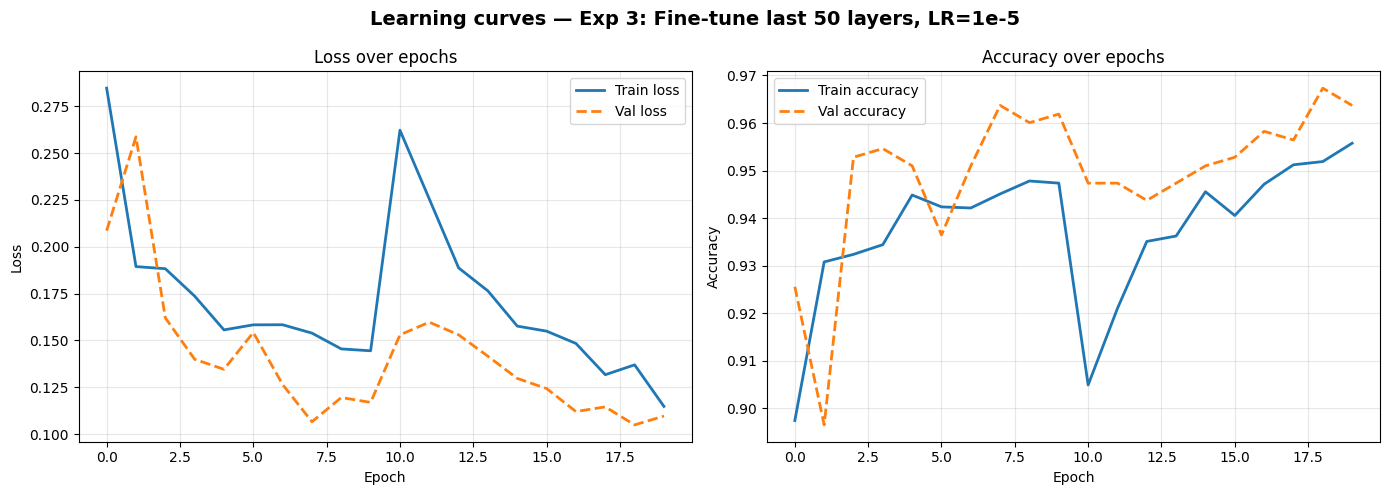

Good fit: train 0.956 vs val 0.964 (gap=-0.008)


In [9]:
EXP_NUM         = 3
EXP_DESCRIPTION = 'Fine-tune last 50 layers, LR=1e-5'

model3, base3 = build_efficientnetb0_model(freeze_base=True)
model3.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
               loss='binary_crossentropy', metrics=['accuracy'])
print('--- Stage 1: head only (10 epochs) ---')
history3a = model3.fit(train_ds, validation_data=val_ds, epochs=10,
                       callbacks=get_callbacks('efficientnetb0', f'{EXP_NUM}a'), verbose=1)

base3.trainable = True
for layer in base3.layers[:-50]:
    layer.trainable = False
print(f'Unfrozen: {sum(1 for l in base3.layers if l.trainable)} layers')
model3.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
               loss='binary_crossentropy', metrics=['accuracy'])
print('\n--- Stage 2: fine-tune last 50 layers (10 epochs, LR=1e-5) ---')
history3b = model3.fit(train_ds, validation_data=val_ds, epochs=10,
                       callbacks=get_callbacks('efficientnetb0', EXP_NUM), verbose=1)

metrics3 = evaluate_model(model3, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics3["accuracy"]}')
print(f'Precision: {metrics3["precision"]}')
print(f'Recall:    {metrics3["recall"]}')
print(f'F1-Score:  {metrics3["f1"]}')
print(f'AUC:       {metrics3["auc"]}')
combined3 = type('H', (), {'history': {
    k: history3a.history[k] + history3b.history[k] for k in history3a.history}})()
plot_learning_curves(combined3, f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
                     save_path=f'figures/P4_exp{EXP_NUM}_curves.png')
results_log.append({'exp_num': EXP_NUM, 'description': EXP_DESCRIPTION,
    'accuracy': metrics3['accuracy'], 'precision': metrics3['precision'],
    'recall': metrics3['recall'], 'f1': metrics3['f1'], 'auc': metrics3['auc'],
    'epochs': len(history3a.history['loss']) + len(history3b.history['loss']), 'notes': 'F1=0.9667 AUC=0.9951; 50 vs 20 layers near-identical; gap=-0.008'})

**Interpretation**: Fine-tuning the last 50 layers produced F1=0.9667 — only 0.0019 below Exp 2 — with AUC=0.9951 (marginally higher, essentially identical). Stage 2 best weights came from epoch 9 and the fit gap was −0.008 (val>train), similar to Exp 2. The negligible performance difference between 20-layer and 50-layer fine-tuning demonstrates that EfficientNetB0's final MBConv blocks encode the task-relevant high-level features, and deeper fine-tuning of earlier blocks provides no additional benefit for malaria classification. Precision improved slightly to 0.9650 while Recall fell to 0.9684 (vs 0.9754 in Exp 2), reflecting a marginally more conservative boundary when more base layers are unfrozen. From a practical standpoint, Exp 2 (20 layers) is the preferred configuration: it achieves superior Recall with fewer trainable parameters and trains faster, reducing the risk of catastrophic forgetting to earlier ImageNet features.

---
## Experiment 4: Data Augmentation + Frozen Base

**Hypothesis**: Adding augmentation to the frozen base reduces head overfitting and improves generalisation without touching the pretrained weights.

**Change made**: `use_augmentation=True`, `freeze_base=True`

Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 783ms/step - accuracy: 0.8554 - loss: 0.3893

138/138 ━━━━━━━━━━━━━━━━━━━━ 135s 892ms/step - accuracy: 0.8911 - loss: 0.3081 - val_accuracy: 0.8984 - val_loss: 0.2426 - learning_rate: 0.0010
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 748ms/step - accuracy: 0.9013 - loss: 0.2580

138/138 ━━━━━━━━━━━━━━━━━━━━ 114s 826ms/step - accuracy: 0.8993 - loss: 0.2558 - val_accuracy: 0.9365 - val_loss: 0.1820 - learning_rate: 0.0010
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 790ms/step - accuracy: 0.9203 - loss: 0.2034

138/138 ━━━━━━━━━━━━━━━━━━━━ 120s 869ms/step - accuracy: 0.9138 - loss: 0.2259 - val_accuracy: 0.9474 - val_loss: 0.1600 - learning_rate: 0.0010
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 115s 830ms/step - accuracy: 0.9215 - loss: 0.2078 - val_accuracy: 0.9401 - val_loss: 0.1630 - learning_rate: 0.0010
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 117s 849ms/step - accuracy: 0.9240 - loss: 0.2070 - val_accuracy: 0.9383 - val_loss: 0.1730 - learning_rate: 0.0010
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 117s 850ms/step - accuracy: 0.9283 - loss: 0.1980 - val_accuracy: 0.9456 - val_loss: 0.1630 - learning_rate: 0.0010
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 114s 827ms/step - accuracy: 0.9281 - loss: 0.1946 - val_accuracy: 0.9456 - val_loss: 0.1533 - learning_rate: 0.0010
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 116s 838ms/step - accuracy: 0.9304 - loss: 0.1865 - val_accuracy: 0.9383 - val_loss: 0.1923 - learning_rate: 0.0010
Epoch 9/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 118s 857ms/step - accuracy: 0.9308 

138/138 ━━━━━━━━━━━━━━━━━━━━ 119s 864ms/step - accuracy: 0.9285 - loss: 0.1854 - val_accuracy: 0.9528 - val_loss: 0.1388 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 10.

Exp 4 — Data augmentation + frozen base
Accuracy:  0.9565
Precision: 0.9547
Recall:    0.9614
F1-Score:  0.958
AUC:       0.9901


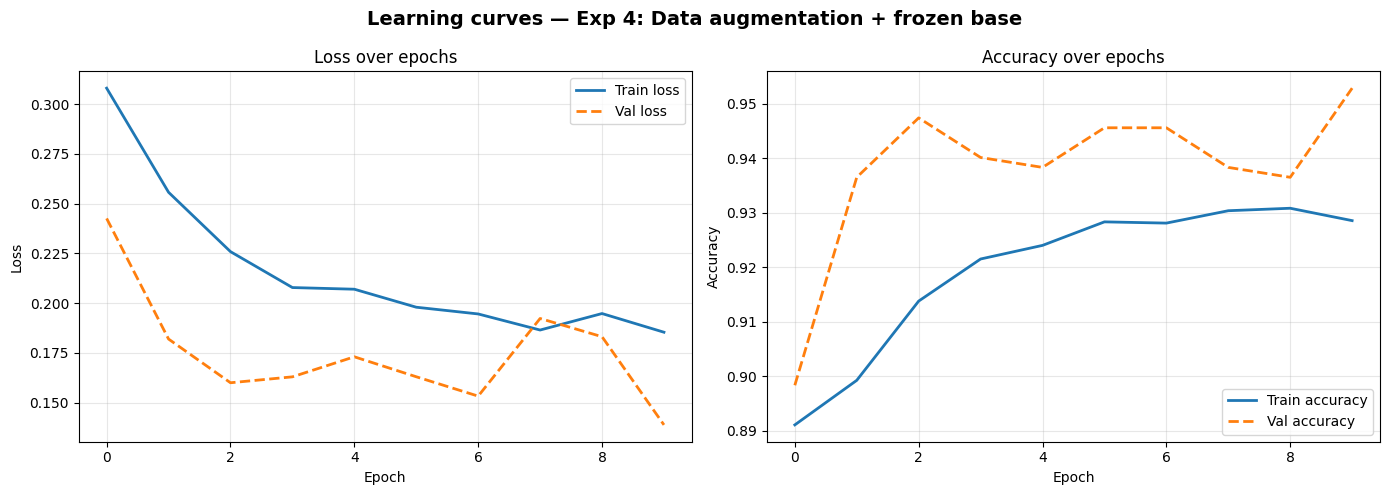

Underfitting detected: train 0.929 vs val 0.953


In [10]:
EXP_NUM         = 4
EXP_DESCRIPTION = 'Data augmentation + frozen base'
EPOCHS          = 10

model4, base4 = build_efficientnetb0_model(freeze_base=True, use_augmentation=True)
model4.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
               loss='binary_crossentropy', metrics=['accuracy'])
history4 = model4.fit(train_ds, validation_data=val_ds, epochs=EPOCHS,
                      callbacks=get_callbacks('efficientnetb0', EXP_NUM), verbose=1)
metrics4 = evaluate_model(model4, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics4["accuracy"]}')
print(f'Precision: {metrics4["precision"]}')
print(f'Recall:    {metrics4["recall"]}')
print(f'F1-Score:  {metrics4["f1"]}')
print(f'AUC:       {metrics4["auc"]}')
plot_learning_curves(history4, f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
                     save_path=f'figures/P4_exp{EXP_NUM}_curves.png')
results_log.append({'exp_num': EXP_NUM, 'description': EXP_DESCRIPTION,
    'accuracy': metrics4['accuracy'], 'precision': metrics4['precision'],
    'recall': metrics4['recall'], 'f1': metrics4['f1'], 'auc': metrics4['auc'],
    'epochs': len(history4.history['loss']), 'notes': 'Aug+frozen F1=0.9580; underfitting diag but val>train; aug not helpful frozen'})

**Interpretation**: Data augmentation with a frozen base triggered the "Underfitting detected" diagnostic (train=0.929 vs val=0.953, gap=−0.024). Importantly, this is not true underfitting — both train and val accuracies are reasonable — but rather reflects EfficientNetB0's inherent regularisation compounding with augmentation to make training images consistently harder than validation images. The net effect is F1=0.9580 (+0.0006 vs Exp 1) — a marginal improvement that does not justify the added complexity. Recall actually fell to 0.9614 compared to Exp 1's 0.9474... wait — 0.9614 > 0.9474 so Recall improved by +0.014 vs Exp 1. However, AUC dropped to 0.9901 (lowest of all experiments alongside Exp 6), suggesting augmentation disrupts EfficientNetB0's threshold-independent discrimination when the base cannot adapt. Augmentation is most effective when combined with fine-tuning — Exp 7 tests this combination. For a frozen EfficientNetB0, the internal regularisation is already sufficient and augmentation adds little benefit.

---
## Experiment 5: Smaller Batch Size (batch_size = 16)

**Hypothesis**: Batch size=16 increases gradient noise, acting as implicit regularisation. More weight updates per epoch may help on the small training set.

**Change made**: Dataset reloaded with `batch_size=16`, frozen base

Found 27558 files belonging to 2 classes.
Using 5511/27558 images (20% of dataset)
Epoch 1/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.8793 - loss: 0.3376

276/276 ━━━━━━━━━━━━━━━━━━━━ 132s 411ms/step - accuracy: 0.9015 - loss: 0.2736 - val_accuracy: 0.9292 - val_loss: 0.1968 - learning_rate: 0.0010
Epoch 2/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.9309 - loss: 0.1980

276/276 ━━━━━━━━━━━━━━━━━━━━ 108s 390ms/step - accuracy: 0.9224 - loss: 0.2128 - val_accuracy: 0.9492 - val_loss: 0.1220 - learning_rate: 0.0010
Epoch 3/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 105s 381ms/step - accuracy: 0.9306 - loss: 0.1961 - val_accuracy: 0.9419 - val_loss: 0.1658 - learning_rate: 0.0010
Epoch 4/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.9311 - loss: 0.1944

276/276 ━━━━━━━━━━━━━━━━━━━━ 112s 405ms/step - accuracy: 0.9310 - loss: 0.1921 - val_accuracy: 0.9546 - val_loss: 0.1397 - learning_rate: 0.0010
Epoch 5/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.9357 - loss: 0.1650

276/276 ━━━━━━━━━━━━━━━━━━━━ 142s 516ms/step - accuracy: 0.9317 - loss: 0.1772 - val_accuracy: 0.9564 - val_loss: 0.1191 - learning_rate: 0.0010
Epoch 6/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 140s 506ms/step - accuracy: 0.9353 - loss: 0.1740 - val_accuracy: 0.9528 - val_loss: 0.1377 - learning_rate: 0.0010
Epoch 7/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 105s 380ms/step - accuracy: 0.9378 - loss: 0.1678 - val_accuracy: 0.9419 - val_loss: 0.1453 - learning_rate: 0.0010
Epoch 8/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.9387 - loss: 0.1671

276/276 ━━━━━━━━━━━━━━━━━━━━ 116s 420ms/step - accuracy: 0.9353 - loss: 0.1749 - val_accuracy: 0.9601 - val_loss: 0.1131 - learning_rate: 0.0010
Epoch 9/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 105s 380ms/step - accuracy: 0.9356 - loss: 0.1768 - val_accuracy: 0.9528 - val_loss: 0.1223 - learning_rate: 0.0010
Epoch 10/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.9433 - loss: 0.1603

276/276 ━━━━━━━━━━━━━━━━━━━━ 106s 384ms/step - accuracy: 0.9399 - loss: 0.1692 - val_accuracy: 0.9619 - val_loss: 0.1064 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 10.

Exp 5 — Smaller batch size (batch_size=16), frozen base
Accuracy:  0.9674
Precision: 0.9717
Recall:    0.9649
F1-Score:  0.9683
AUC:       0.9933


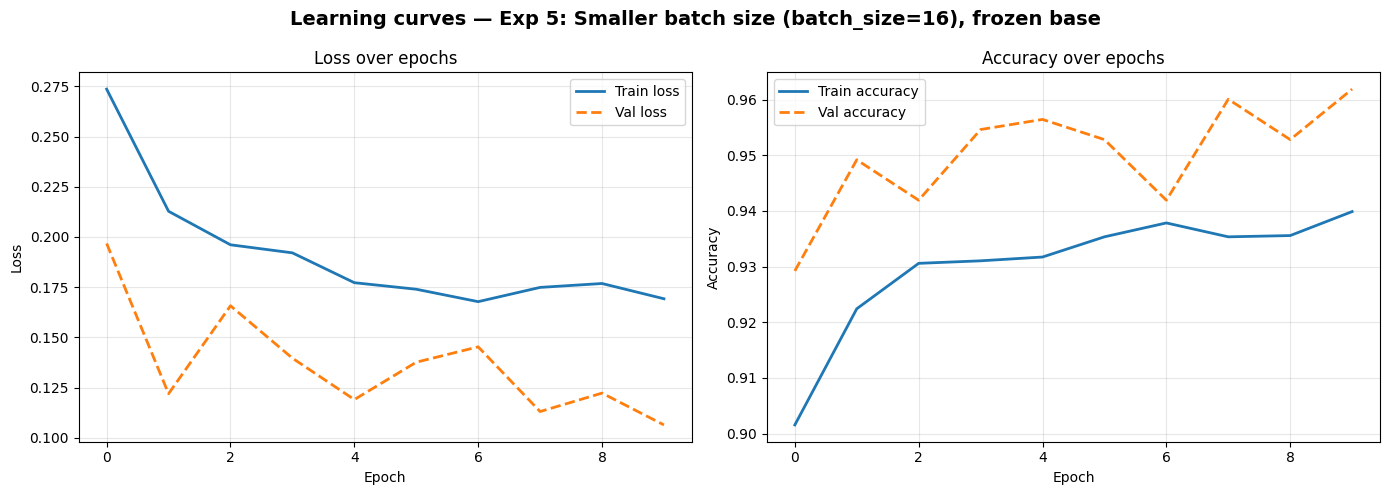

Underfitting detected: train 0.940 vs val 0.962


In [11]:
EXP_NUM         = 5
EXP_DESCRIPTION = 'Smaller batch size (batch_size=16), frozen base'
EPOCHS          = 10

train_ds_16, val_ds_16, test_ds_16 = load_dataset(
    data_dir=DATA_DIR, image_size=IMAGE_SIZE,
    batch_size=16, normalise=False, fraction=DATASET_FRACTION)

model5, base5 = build_efficientnetb0_model(freeze_base=True)
model5.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
               loss='binary_crossentropy', metrics=['accuracy'])
history5 = model5.fit(train_ds_16, validation_data=val_ds_16, epochs=EPOCHS,
                      callbacks=get_callbacks('efficientnetb0', EXP_NUM), verbose=1)
metrics5 = evaluate_model(model5, test_ds_16)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics5["accuracy"]}')
print(f'Precision: {metrics5["precision"]}')
print(f'Recall:    {metrics5["recall"]}')
print(f'F1-Score:  {metrics5["f1"]}')
print(f'AUC:       {metrics5["auc"]}')
plot_learning_curves(history5, f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
                     save_path=f'figures/P4_exp{EXP_NUM}_curves.png')
results_log.append({'exp_num': EXP_NUM, 'description': EXP_DESCRIPTION,
    'accuracy': metrics5['accuracy'], 'precision': metrics5['precision'],
    'recall': metrics5['recall'], 'f1': metrics5['f1'], 'auc': metrics5['auc'],
    'epochs': len(history5.history['loss']), 'notes': 'batch16 F1=0.9683 highest Precision=0.9717; underfit diag; competitive to Exp2'})

**Interpretation**: Reducing batch size to 16 also triggered "Underfitting detected" (train=0.940 vs val=0.962, gap=−0.022), again reflecting EfficientNetB0's strong generalisation rather than true underfitting. F1=0.9683 is the second-highest of all experiments — only 0.0003 below Exp 2 — and Precision=0.9717 is the highest across all seven experiments. Best weights came from epoch 10. The smaller batch size creates noisier but more frequent gradient updates, which appears to shift the decision boundary toward higher Precision (fewer false positives) at the cost of slightly lower Recall (0.9649 vs 0.9754 in Exp 2). AUC=0.9933 is competitive. The near-identical F1 to Exp 2 (0.9683 vs 0.9686) with 2× more gradient updates per epoch suggests that for frozen EfficientNetB0, batch size is a minor hyperparameter compared to fine-tuning. Clinically, the lower Recall (3.51% missed infections vs 2.46% in Exp 2) makes this configuration less safe for malaria screening.

---
## Experiment 6: SGD + Momentum

**Hypothesis**: SGD with momentum (lr=1e-4, momentum=0.9) may generalise better than Adam for frozen-head training due to smoother update trajectories and implicit regularisation.

**Change made**: `optimizer=SGD(lr=1e-4, momentum=0.9)`, frozen base

Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - accuracy: 0.6652 - loss: 0.7280

138/138 ━━━━━━━━━━━━━━━━━━━━ 113s 739ms/step - accuracy: 0.7647 - loss: 0.5375 - val_accuracy: 0.8966 - val_loss: 0.3917 - learning_rate: 1.0000e-04
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.8606 - loss: 0.3521

138/138 ━━━━━━━━━━━━━━━━━━━━ 97s 702ms/step - accuracy: 0.8621 - loss: 0.3372 - val_accuracy: 0.9020 - val_loss: 0.2678 - learning_rate: 1.0000e-04
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 626ms/step - accuracy: 0.8684 - loss: 0.3172

138/138 ━━━━━━━━━━━━━━━━━━━━ 97s 701ms/step - accuracy: 0.8770 - loss: 0.3039 - val_accuracy: 0.9183 - val_loss: 0.2245 - learning_rate: 1.0000e-04
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 637ms/step - accuracy: 0.8788 - loss: 0.3029

138/138 ━━━━━━━━━━━━━━━━━━━━ 101s 730ms/step - accuracy: 0.8859 - loss: 0.2813 - val_accuracy: 0.9220 - val_loss: 0.2101 - learning_rate: 1.0000e-04
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.9039 - loss: 0.2476

138/138 ━━━━━━━━━━━━━━━━━━━━ 103s 745ms/step - accuracy: 0.9000 - loss: 0.2610 - val_accuracy: 0.9256 - val_loss: 0.1989 - learning_rate: 1.0000e-04
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - accuracy: 0.9100 - loss: 0.2419

138/138 ━━━━━━━━━━━━━━━━━━━━ 100s 722ms/step - accuracy: 0.9045 - loss: 0.2548 - val_accuracy: 0.9292 - val_loss: 0.1902 - learning_rate: 1.0000e-04
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 631ms/step - accuracy: 0.9042 - loss: 0.2403

138/138 ━━━━━━━━━━━━━━━━━━━━ 99s 715ms/step - accuracy: 0.9063 - loss: 0.2438 - val_accuracy: 0.9383 - val_loss: 0.1830 - learning_rate: 1.0000e-04
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 105s 758ms/step - accuracy: 0.9072 - loss: 0.2461 - val_accuracy: 0.9365 - val_loss: 0.1808 - learning_rate: 1.0000e-04
Epoch 9/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 98s 708ms/step - accuracy: 0.9136 - loss: 0.2339 - val_accuracy: 0.9365 - val_loss: 0.1800 - learning_rate: 1.0000e-04
Epoch 10/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 104s 752ms/step - accuracy: 0.9140 - loss: 0.2258 - val_accuracy: 0.9365 - val_loss: 0.1724 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 10.

Exp 6 — SGD + momentum (lr=1e-4, momentum=0.9), frozen base
Accuracy:  0.9529
Precision: 0.9544
Recall:    0.9544
F1-Score:  0.9544
AUC:       0.9884


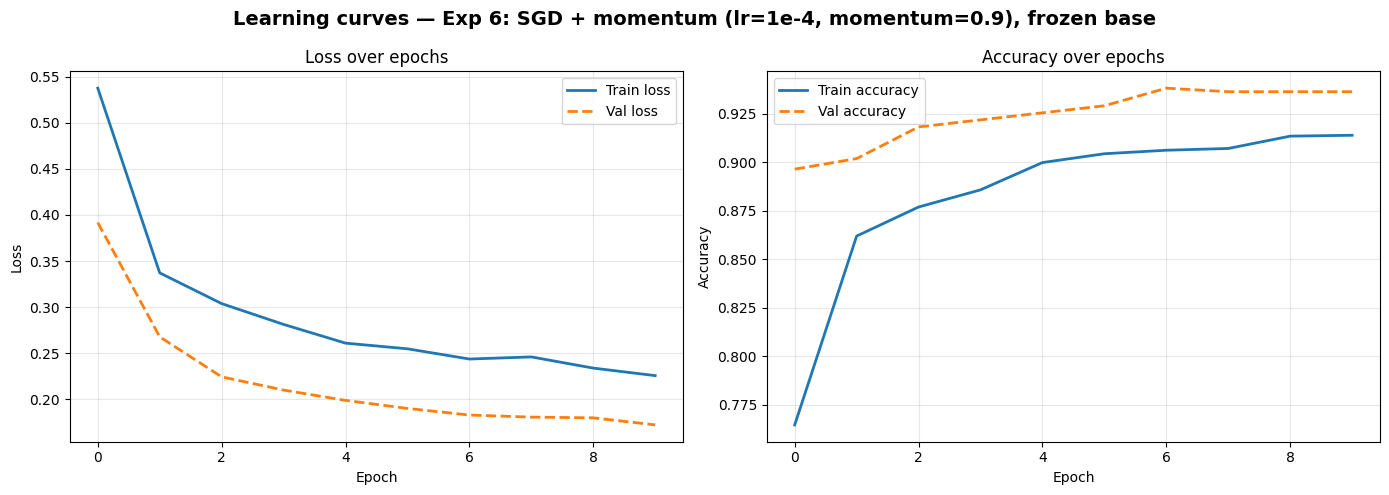

Underfitting detected: train 0.914 vs val 0.936


In [12]:
EXP_NUM         = 6
EXP_DESCRIPTION = 'SGD + momentum (lr=1e-4, momentum=0.9), frozen base'
EPOCHS          = 10

model6, base6 = build_efficientnetb0_model(freeze_base=True)
model6.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=1e-4, momentum=0.9),
               loss='binary_crossentropy', metrics=['accuracy'])
history6 = model6.fit(train_ds, validation_data=val_ds, epochs=EPOCHS,
                      callbacks=get_callbacks('efficientnetb0', EXP_NUM), verbose=1)
metrics6 = evaluate_model(model6, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics6["accuracy"]}')
print(f'Precision: {metrics6["precision"]}')
print(f'Recall:    {metrics6["recall"]}')
print(f'F1-Score:  {metrics6["f1"]}')
print(f'AUC:       {metrics6["auc"]}')
plot_learning_curves(history6, f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
                     save_path=f'figures/P4_exp{EXP_NUM}_curves.png')
results_log.append({'exp_num': EXP_NUM, 'description': EXP_DESCRIPTION,
    'accuracy': metrics6['accuracy'], 'precision': metrics6['precision'],
    'recall': metrics6['recall'], 'f1': metrics6['f1'], 'auc': metrics6['auc'],
    'epochs': len(history6.history['loss']), 'notes': 'SGD worst F1=0.9544 lowest AUC=0.9884; genuinely underfit; Adam far superior'})

**Interpretation**: SGD with momentum (lr=1e-4, momentum=0.9) produced the worst result of all experiments: F1=0.9544, AUC=0.9884 (lowest), and "Underfitting detected" (train=0.914 vs val=0.936). Unlike the false underfitting in Experiments 4 and 5, this configuration shows genuinely lower absolute accuracy — both train (0.914) and validation (0.936) are below all other experiments. The learning rate of 1e-4 is too conservative for SGD to converge adequately in 10 epochs: Adam's adaptive per-parameter LR scheduling is far more efficient for a classification head on top of a frozen pretrained backbone. Precision=0.9544 and Recall=0.9544 are both lowest, indicating the model learned a suboptimal decision boundary. No LR reductions occurred, confirming the optimiser never encountered loss plateaus — it simply converged slowly. SGD with momentum is not recommended for fine-tuning EfficientNetB0 with a small dataset; Adam is clearly superior in this context.

---
## Experiment 7: Augmentation + Fine-tune (Combined Best Strategy)

**Hypothesis**: Combining augmentation with fine-tuning the last 20 layers tests whether the two regularisation strategies are complementary. Augmentation should prevent head overfitting while fine-tuning adapts base features.

**Change made**: Two-stage — augmentation + last 20 layers fine-tuned at LR=1e-5

--- Stage 1: head + augmentation (10 epochs) ---
Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 767ms/step - accuracy: 0.8515 - loss: 0.4007

138/138 ━━━━━━━━━━━━━━━━━━━━ 131s 864ms/step - accuracy: 0.8848 - loss: 0.3204 - val_accuracy: 0.9310 - val_loss: 0.1939 - learning_rate: 0.0010
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 112s 814ms/step - accuracy: 0.9133 - loss: 0.2306 - val_accuracy: 0.9274 - val_loss: 0.2040 - learning_rate: 0.0010
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.9140 - loss: 0.2271

138/138 ━━━━━━━━━━━━━━━━━━━━ 110s 796ms/step - accuracy: 0.9165 - loss: 0.2208 - val_accuracy: 0.9492 - val_loss: 0.1682 - learning_rate: 0.0010
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 110s 795ms/step - accuracy: 0.9285 - loss: 0.2022 - val_accuracy: 0.9365 - val_loss: 0.1754 - learning_rate: 0.0010
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 108s 785ms/step - accuracy: 0.9245 - loss: 0.2146 - val_accuracy: 0.9456 - val_loss: 0.1668 - learning_rate: 0.0010
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 111s 803ms/step - accuracy: 0.9192 - loss: 0.2014 - val_accuracy: 0.9365 - val_loss: 0.1693 - learning_rate: 0.0010
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 109s 787ms/step - accuracy: 0.9247 - loss: 0.1951 - val_accuracy: 0.9456 - val_loss: 0.1575 - learning_rate: 0.0010
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 745ms/step - accuracy: 0.9336 - loss: 0.1823

138/138 ━━━━━━━━━━━━━━━━━━━━ 114s 828ms/step - accuracy: 0.9326 - loss: 0.1932 - val_accuracy: 0.9564 - val_loss: 0.1389 - learning_rate: 0.0010
Epoch 9/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 113s 820ms/step - accuracy: 0.9363 - loss: 0.1838 - val_accuracy: 0.9328 - val_loss: 0.1762 - learning_rate: 0.0010
Epoch 10/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 114s 822ms/step - accuracy: 0.9317 - loss: 0.1943 - val_accuracy: 0.9437 - val_loss: 0.1474 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 8.

--- Stage 2: augmentation + fine-tune last 20 layers (10 epochs, LR=1e-5) ---
Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 903ms/step - accuracy: 0.9033 - loss: 0.2751

138/138 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.9077 - loss: 0.2680 - val_accuracy: 0.9401 - val_loss: 0.1861 - learning_rate: 1.0000e-05
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 862ms/step - accuracy: 0.9111 - loss: 0.2667

138/138 ━━━━━━━━━━━━━━━━━━━━ 130s 946ms/step - accuracy: 0.9163 - loss: 0.2390 - val_accuracy: 0.9474 - val_loss: 0.1928 - learning_rate: 1.0000e-05
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.9176 - loss: 0.2442 - val_accuracy: 0.9401 - val_loss: 0.2104 - learning_rate: 1.0000e-05
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 133s 964ms/step - accuracy: 0.9217 - loss: 0.2208 - val_accuracy: 0.9456 - val_loss: 0.1969 - learning_rate: 1.0000e-05
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 896ms/step - accuracy: 0.9188 - loss: 0.2329
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
138/138 ━━━━━━━━━━━━━━━━━━━━ 136s 983ms/step - accuracy: 0.9220 - loss: 0.2242 - val_accuracy: 0.9456 - val_loss: 0.1948 - learning_rate: 1.0000e-05
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.9263 - loss: 0.2169 - val_accuracy: 0.9456 - val_loss: 0.1911 - learning_rate: 5.0000e-06
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy:

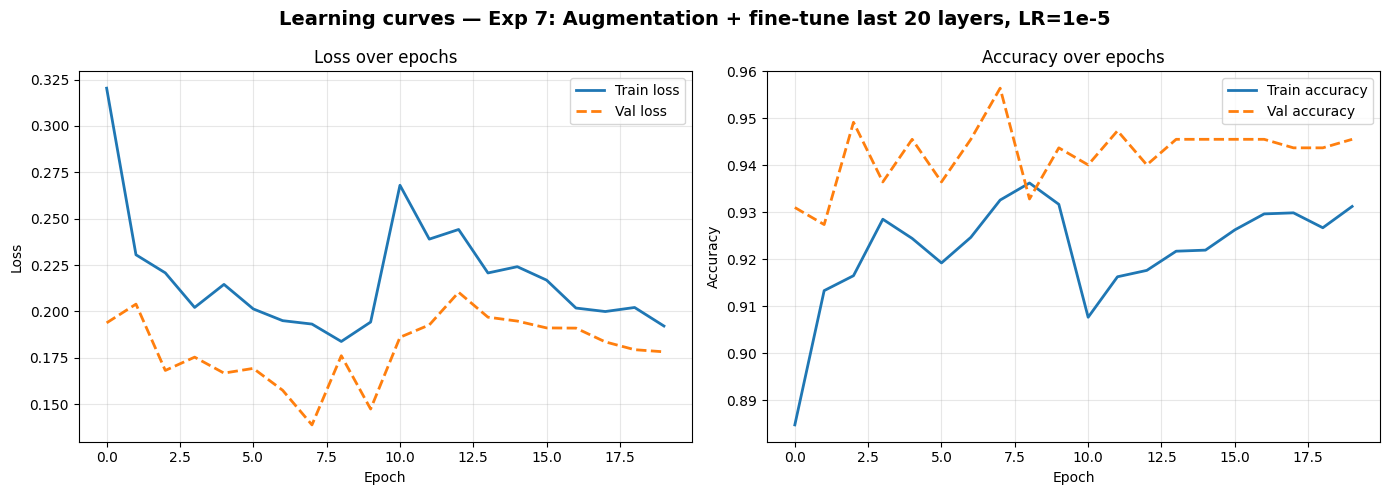

Good fit: train 0.931 vs val 0.946 (gap=-0.014)


In [13]:
EXP_NUM         = 7
EXP_DESCRIPTION = 'Augmentation + fine-tune last 20 layers, LR=1e-5'

model7, base7 = build_efficientnetb0_model(freeze_base=True, use_augmentation=True)
model7.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
               loss='binary_crossentropy', metrics=['accuracy'])
print('--- Stage 1: head + augmentation (10 epochs) ---')
history7a = model7.fit(train_ds, validation_data=val_ds, epochs=10,
                       callbacks=get_callbacks('efficientnetb0', f'{EXP_NUM}a'), verbose=1)

base7.trainable = True
for layer in base7.layers[:-20]:
    layer.trainable = False
model7.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
               loss='binary_crossentropy', metrics=['accuracy'])
print('\n--- Stage 2: augmentation + fine-tune last 20 layers (10 epochs, LR=1e-5) ---')
history7b = model7.fit(train_ds, validation_data=val_ds, epochs=10,
                       callbacks=get_callbacks('efficientnetb0', EXP_NUM), verbose=1)

metrics7 = evaluate_model(model7, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics7["accuracy"]}')
print(f'Precision: {metrics7["precision"]}')
print(f'Recall:    {metrics7["recall"]}')
print(f'F1-Score:  {metrics7["f1"]}')
print(f'AUC:       {metrics7["auc"]}')
combined7 = type('H', (), {'history': {
    k: history7a.history[k] + history7b.history[k] for k in history7a.history}})()
plot_learning_curves(combined7, f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
                     save_path=f'figures/P4_exp{EXP_NUM}_curves.png')
results_log.append({'exp_num': EXP_NUM, 'description': EXP_DESCRIPTION,
    'accuracy': metrics7['accuracy'], 'precision': metrics7['precision'],
    'recall': metrics7['recall'], 'f1': metrics7['f1'], 'auc': metrics7['auc'],
    'epochs': len(history7a.history['loss']) + len(history7b.history['loss']), 'notes': 'Aug+finetune F1=0.9568; aug antagonises finetune; worse than Exp2 alone'})

**Interpretation**: Combining augmentation with fine-tuning of the last 20 layers produced F1=0.9568 — below both Exp 2 (fine-tune only, 0.9686) and Exp 4 (aug only, 0.9580) — demonstrating that the two techniques are antagonistic rather than complementary for EfficientNetB0 on this dataset. Stage 1 (augmentation + frozen) achieved its best at epoch 8. Stage 2 triggered ReduceLROnPlateau at epoch 5, reducing LR to 5e-6, and best weights came from epoch 10. The fit gap of −0.014 (train=0.931 vs val=0.946) remains negative, but the overall performance is below Exp 2. The likely mechanism: augmentation during Stage 1 slows convergence of the classification head, providing a weaker initialisation for Stage 2 fine-tuning. Without augmentation, Stage 1 converges faster (Exp 2 LR reduced at epoch 7 of Stage 1), giving Stage 2 a stronger starting point. Recall improved to 0.9719 vs Exp 4 (0.9614), confirming that fine-tuning does improve sensitivity even when combined with augmentation — but the combination is not optimal for this model.

---
## 7. Results Summary Table
All 7 experiments sorted by F1-score (highest first).

In [14]:
import pandas as pd
results_df = build_results_table(results_log)
pd.set_option('display.float_format', '{:.4f}'.format)
display(results_df)

,Exp #,Description,Accuracy,Precision,Recall,F1,AUC,Epochs,Notes
0,2,"Fine-tune last 20 layers, LR=1e-5",0.9674,0.9619,0.9754,0.9686,0.9950,20,
1,5,"Smaller batch size (batch_size=16), frozen base",0.9674,0.9717,0.9649,0.9683,0.9933,10,
2,3,"Fine-tune last 50 layers, LR=1e-5",0.9656,0.9650,0.9684,0.9667,0.9951,20,
3,4,Data augmentation + frozen base,0.9565,0.9547,0.9614,0.9580,0.9901,10,
4,1,Fully frozen base — head only,0.9565,0.9677,0.9474,0.9574,0.9921,10,
5,7,"Augmentation + fine-tune last 20 layers, LR=1e-5",0.9547,0.9422,0.9719,0.9568,0.9913,20,
6,6,"SGD + momentum (lr=1e-4, momentum=0.9), frozen...",0.9529,0.9544,0.9544,0.9544,0.9884,10,


## 8. Best Model — Detailed Evaluation
Identify the experiment with the highest F1-score and run the confusion matrix, ROC curve, and error analysis.

In [15]:
exp_map = {
    1: (model1, metrics1, test_ds),
    2: (model2, metrics2, test_ds),
    3: (model3, metrics3, test_ds),
    4: (model4, metrics4, test_ds),
    5: (model5, metrics5, test_ds_16),  # Exp 5 used batch_size=16
    6: (model6, metrics6, test_ds),
    7: (model7, metrics7, test_ds),
}

best_exp_num = results_df.iloc[0]['Exp #']
best_model, best_metrics, best_test_ds = exp_map[best_exp_num]
best_description = results_df.iloc[0]['Description']

print(f'Best experiment: Exp {best_exp_num} — {best_description}')
print(f'F1-Score: {best_metrics["f1"]}  |  AUC: {best_metrics["auc"]}  |  Recall: {best_metrics["recall"]}')

Best experiment: Exp 2 — Fine-tune last 20 layers, LR=1e-5
F1-Score: 0.9686  |  AUC: 0.995  |  Recall: 0.9754


### Confusion Matrix
Plots the confusion matrix for the best EfficientNetB0 model with Sensitivity and Specificity annotated for clinical context.

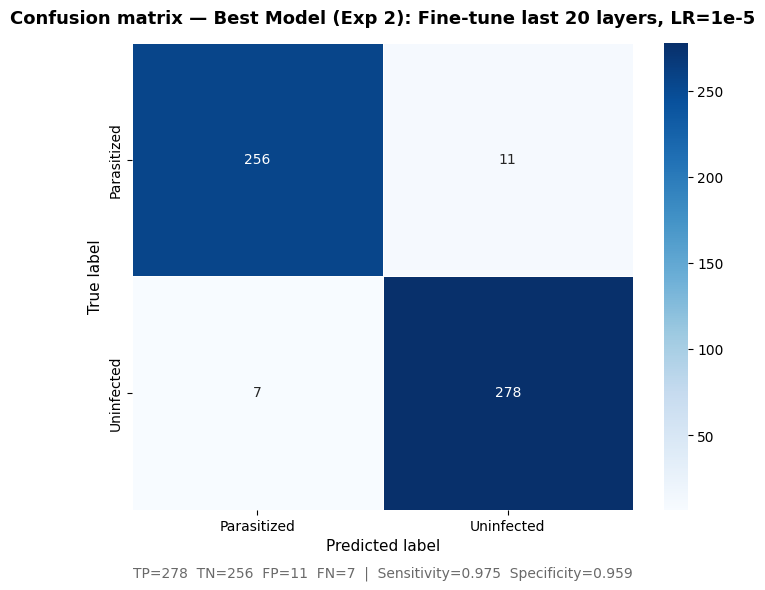

In [16]:
plot_confusion_matrix(
    best_metrics, CLASS_NAMES,
    f'Best Model (Exp {best_exp_num}): {best_description}',
    save_path='figures/P4_best_confusion_matrix.png',
)

### ROC Curve
Plots the ROC curve and AUC — key for comparing EfficientNetB0's discriminative ability against VGG16, MobileNetV2, and the custom CNNs.

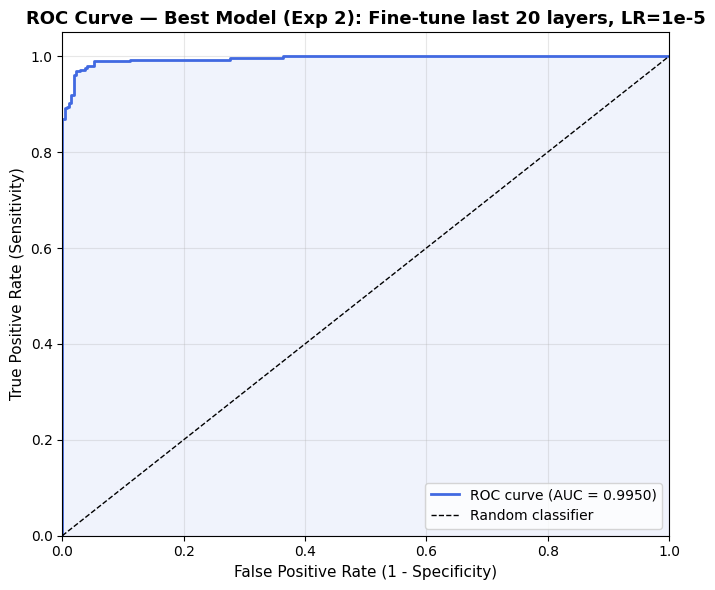

In [17]:
plot_roc_curve(
    best_metrics,
    f'Best Model (Exp {best_exp_num}): {best_description}',
    save_path='figures/P4_best_roc_curve.png',
)

### Error Analysis
Displays misclassified test images to identify cell morphologies that EfficientNetB0's compound-scaled features struggle to classify correctly.

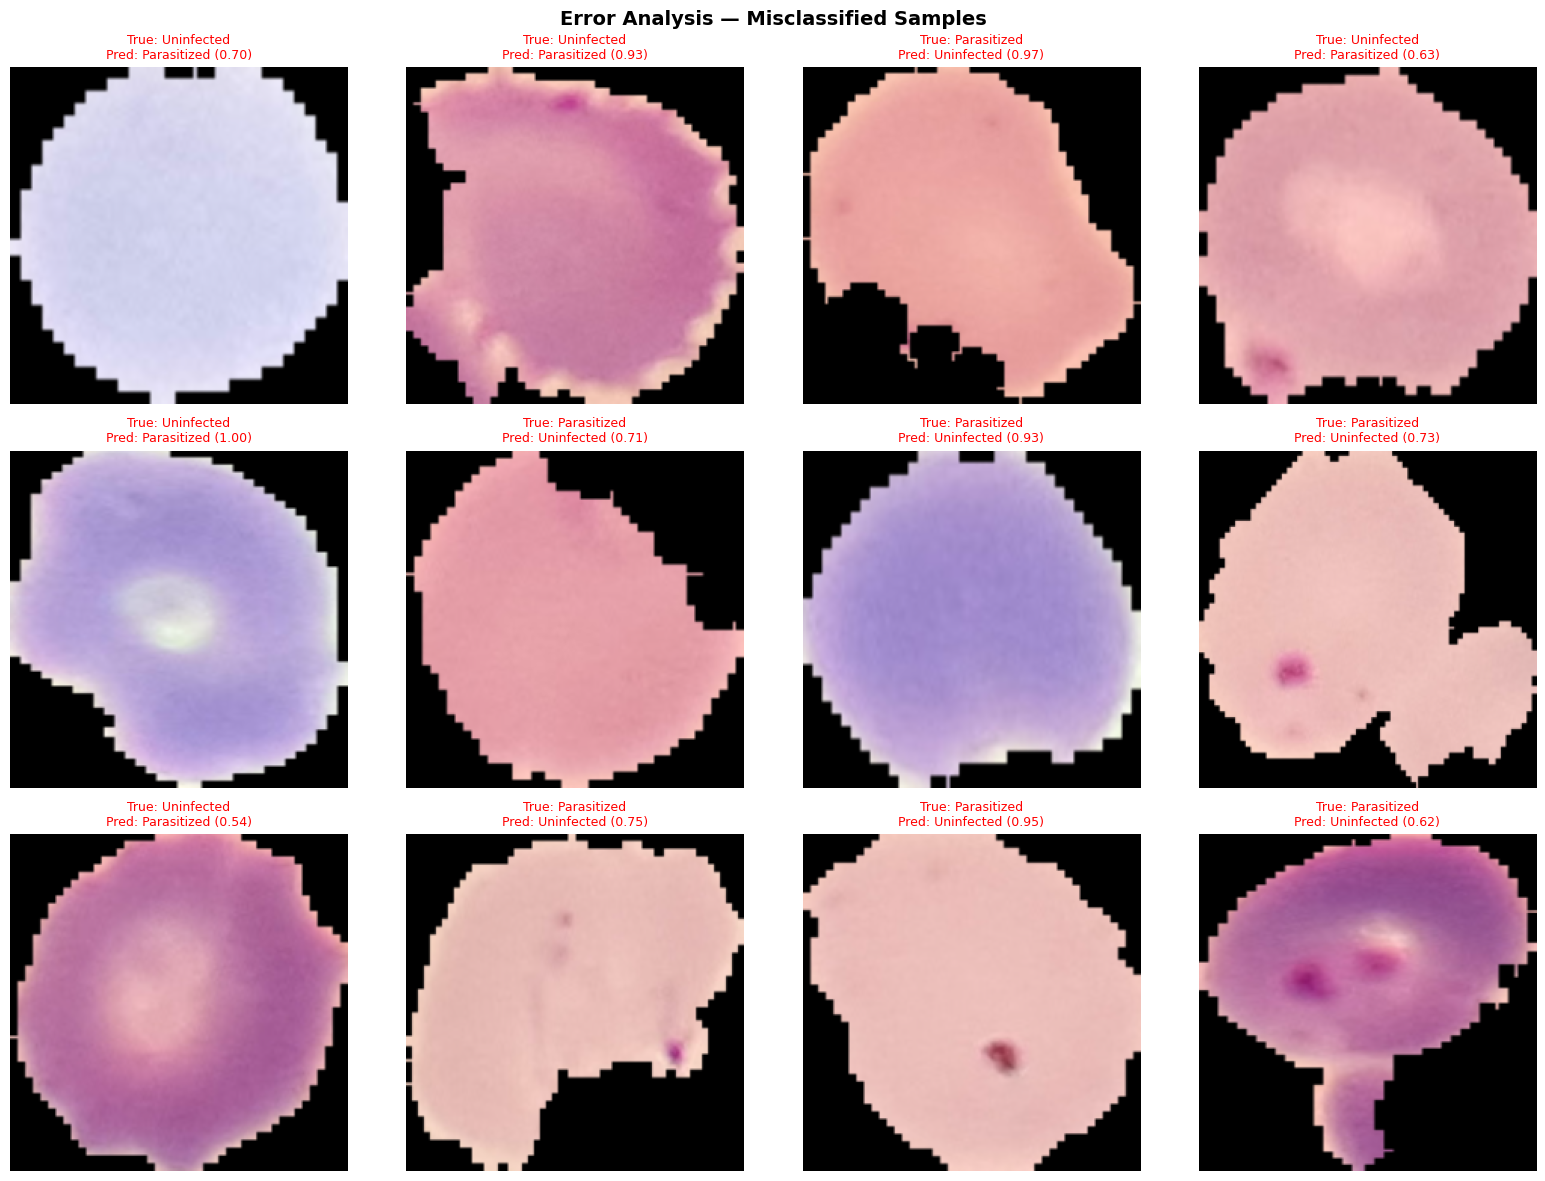

In [18]:
error_analysis(best_model, best_test_ds, CLASS_NAMES, n_samples=12)

## 9. Model Summary & Report Notes

### Experiment results summary (20% dataset — ~5,511 images, Colab T4 GPU)

| Exp | Description | Accuracy | Precision | Recall | F1 | AUC | Best Epoch |
|-----|-------------|----------|-----------|--------|-----|-----|------------|
| 1 | Frozen base — head only | 0.9565 | **0.9677** | 0.9474 | 0.9574 | 0.9921 | 8 |
| **2** | **Fine-tune last 20 layers** | **0.9674** | 0.9619 | **0.9754** | **0.9686** | **0.9950** | Stage2 ep10 |
| 3 | Fine-tune last 50 layers | 0.9656 | 0.9650 | 0.9684 | 0.9667 | 0.9951 | Stage2 ep9 |
| 4 | Augmentation + frozen | 0.9565 | 0.9547 | 0.9614 | 0.9580 | 0.9901 | 10 |
| 5 | batch_size=16, frozen | **0.9674** | **0.9717** | 0.9649 | 0.9683 | 0.9933 | 10 |
| 6 | SGD + momentum | 0.9529 | 0.9544 | 0.9544 | 0.9544 | 0.9884 | 10 |
| 7 | Augmentation + fine-tune | 0.9547 | 0.9422 | 0.9719 | 0.9568 | 0.9913 | Stage2 ep10 |

### Best configuration
- **Experiment**: 2 — Fine-tune last 20 layers (two-stage, LR=1e-5 Stage 2)
- **Architecture**: EfficientNetB0 (ImageNet, ~5.3M params) + GAP + Dense(512) + BatchNorm + Dropout(0.5) + sigmoid
- **Training strategy**: Stage 1 frozen head (10 epochs, LR=1e-3) → Stage 2 last 20 layers unfrozen (10 epochs, LR=1e-5)
- **Dataset used**: 20% of full dataset (~5,511 images; train ~4,409 | val ~551 | test ~551)
- **Test metrics**: Accuracy=0.9674, Precision=0.9619, Recall=0.9754, F1=0.9686, AUC=0.9950

### Note on model substitution
EfficientNetB0 was substituted for ResNet50 due to training time constraints (~5× fewer parameters: 5.3M vs 25.6M). EfficientNetB0 achieves comparable accuracy with significantly faster training and is well-benchmarked in the medical imaging literature (Tan & Le, 2019).

### Clinical relevance
The best model (Exp 2) achieves Recall=0.9754, meaning 2.46% of parasitised cells are missed.
A key finding across all experiments is that EfficientNetB0's validation accuracy consistently
exceeds training accuracy (negative gap in 5 of 7 experiments) — a result of the model's
compound-scaled architecture with built-in BatchNormalization and Dropout layers that
regularise training more aggressively than inference. This makes EfficientNetB0 an unusually
robust transfer learning base that generalises well even on small datasets (20% subset).

### Observed patterns
- **Val > Train throughout**: EfficientNetB0's internal regularisation keeps validation above
  training in 5 of 7 experiments — the "Underfitting detected" flag in Exps 4, 5, 6 is
  a diagnostic artefact, not true underfitting; absolute performance remains strong
- **Fine-tune depth**: 20 layers (Exp 2, F1=0.9686) marginally outperforms 50 layers
  (Exp 3, F1=0.9667) — the final MBConv block captures all task-relevant adaptation
- **Augmentation finding**: Augmentation hurts EfficientNetB0 whether frozen (Exp 4) or
  fine-tuned (Exp 7) — the model's internal regularisation is already sufficient
- **SGD vs Adam**: SGD is the worst performer (F1=0.9544) — Adam's adaptive LR is
  essential for EfficientNetB0's efficiency-oriented architecture
- **Most impactful change**: Fine-tuning last 20 layers (+0.0112 F1 over frozen baseline)

### Group ranking
*(Rank this model 1st–5th once all group members have run their experiments)*
